# Comparing Isochrone 

There’s a visible discrepancy between the GitHub and Jupyter Notebook isochrone methods. This notebook compares them to show why the outputs differ and to confirm the baseline we want going forward.

### Setup 

In [1]:
import folium
from shapely.geometry import mapping
import networkx as nx

# BEFORE (original classes)
from github_isochrone import IsochroneGenerator as GitHubIsochroneGenerator
from notebook_isochrone import IsochroneGenerator as NotebookIsochroneGenerator

# AFTER (updated classes)
from updated_github_isochrone import UpdatedGitHubIsochroneGenerator
from updated_notebook_isochrone import UpdatedNotebookIsochroneGenerator

# Same-map Notebook class: reuse GitHub's OSM graph
class MapUpdatedNotebookIsochroneGenerator(UpdatedNotebookIsochroneGenerator):
    def __init__(self, default_speed=48.28):
        self.default_speed = default_speed
        self.G = None
    def set_graph(self, G: nx.MultiDiGraph):
        self.G = G
        self._MapUpdatedNotebookIsochroneGenerator__update_graph_with_times()
    def _MapUpdatedNotebookIsochroneGenerator__update_graph_with_times(self):
        UpdatedNotebookIsochroneGenerator._UpdatedNotebookIsochroneGenerator__update_graph_with_times(self)

HOSPITALS = {
    "Musgrove Park Hospital": (51.0113, -3.1207),
    "Yeovil Hospital": (50.9448, -2.6343),
}

def overlay_map(poly_a, poly_b, center, labels=("A","B"), zoom=10):
    lat, lon = center
    m = folium.Map(location=[lat, lon], zoom_start=zoom, control_scale=True)
    folium.GeoJson(mapping(poly_a), name=f"{labels[0]} (blue)",
                   style_function=lambda f: {"color": "#1f77b4", "weight": 2, "fillOpacity": 0.10}).add_to(m)
    folium.GeoJson(mapping(poly_b), name=f"{labels[1]} (orange)",
                   style_function=lambda f: {"color": "#ff7f0e", "weight": 2, "fillOpacity": 0.10}).add_to(m)
    folium.LayerControl(collapsed=False).add_to(m)
    return m

### Comparison 1 — Original implementations (no changes)

GitHub method (OSM place-based), Notebook method (local GraphML).

Run as-is; no code changes.

In [ ]:
# Instantiate originals
gh_before = GitHubIsochroneGenerator()
nb_before = NotebookIsochroneGenerator()

# Load OSM for GitHub (Notebook original uses its own GraphML)
gh_before.load_graph(place_name="Somersetshire", network_type="drive")

def make_pair_before(name, minutes=10, alpha=30):
    lat, lon = HOSPITALS[name]
    poly_gh = gh_before.generate_isochrone(
        place_name="Somersetshire",
        isochrone_name=f"{name}_gh_before",
        lat=lat, lon=lon,
        drive_time=minutes, alpha=alpha
    )
    # original Notebook class: turn on concave if you want hull parity
    poly_nb = nb_before.generate_isochrone(
        lat=lat, lon=lon,
        max_drive_time=minutes,
        use_alphashape=True
    )
    return poly_gh, poly_nb

poly_m_gh_b, poly_m_nb_b = make_pair_before("Musgrove Park Hospital")
poly_y_gh_b, poly_y_nb_b = make_pair_before("Yeovil Hospital")

# Folium overlay maps (BEFORE)
m_before_musgrove = overlay_map(poly_m_gh_b, poly_m_nb_b, HOSPITALS["Musgrove Park Hospital"],
                                labels=("GitHub (before)", "Notebook (before)"))
m_before_yeovil   = overlay_map(poly_y_gh_b, poly_y_nb_b, HOSPITALS["Yeovil Hospital"],
                                labels=("GitHub (before)", "Notebook (before)"))

m_before_musgrove  # then run a new cell with: m_before_yeovil

In [4]:
m_before_yeovil

### Comparison 2 — Same logic, different data

Remove speed multiplier. 

Use concave hull (alphashape) in both. 

Keep each method’s original network source (OSM vs GraphML).

In [5]:
gh_after = UpdatedGitHubIsochroneGenerator()
nb_after = UpdatedNotebookIsochroneGenerator()

gh_after.load_graph(place_name="Somersetshire", network_type="drive")

def make_pair_after(name, minutes=10, alpha=30):
    lat, lon = HOSPITALS[name]
    poly_gh = gh_after.generate_isochrone(
        place_name="Somersetshire",
        isochrone_name=f"{name}_gh_after",
        lat=lat, lon=lon,
        drive_time=minutes, alpha=alpha
    )
    poly_nb = nb_after.generate_isochrone(
        lat=lat, lon=lon,
        max_drive_time=minutes,
        alpha=alpha
    )
    return poly_gh, poly_nb

poly_m_gh_a, poly_m_nb_a = make_pair_after("Musgrove Park Hospital")
poly_y_gh_a, poly_y_nb_a = make_pair_after("Yeovil Hospital")

m_after_musgrove = overlay_map(poly_m_gh_a, poly_m_nb_a, HOSPITALS["Musgrove Park Hospital"],
                               labels=("Updated GitHub", "Updated Notebook"))
m_after_yeovil   = overlay_map(poly_y_gh_a, poly_y_nb_a, HOSPITALS["Yeovil Hospital"],
                               labels=("Updated GitHub", "Updated Notebook"))

m_after_musgrove  # then: m_after_yeovil

In [6]:
m_after_yeovil

### Comparison 3 — Same logic, same map

Reuse the exact OSM graph for both methods.

Keep concave hull (alphashape) and aligned speed handling.

In [7]:
gh_same = UpdatedGitHubIsochroneGenerator()
nb_same = MapUpdatedNotebookIsochroneGenerator()

gh_same.load_graph(place_name="Somersetshire", network_type="drive")
nb_same.set_graph(gh_same.G)

def make_pair_same_map(name, minutes=10, alpha=30):
    lat, lon = HOSPITALS[name]
    poly_gh = gh_same.generate_isochrone(
        place_name="Somersetshire",
        isochrone_name=f"{name}_gh_same",
        lat=lat, lon=lon,
        drive_time=minutes, alpha=alpha
    )
    poly_nb = nb_same.generate_isochrone(
        lat=lat, lon=lon,
        max_drive_time=minutes,
        alpha=alpha
    )
    return poly_gh, poly_nb

poly_m_gh_s, poly_m_nb_s = make_pair_same_map("Musgrove Park Hospital")
poly_y_gh_s, poly_y_nb_s = make_pair_same_map("Yeovil Hospital")

m_same_musgrove = overlay_map(poly_m_gh_s, poly_m_nb_s, HOSPITALS["Musgrove Park Hospital"],
                              labels=("Updated GitHub", "Notebook (same map)"))
m_same_yeovil   = overlay_map(poly_y_gh_s, poly_y_nb_s, HOSPITALS["Yeovil Hospital"],
                              labels=("Updated GitHub", "Notebook (same map)"))

m_same_musgrove  # then: m_same_yeovil

In [8]:
m_same_yeovil

#### Correct map usage

It's important to know what the previously installed road network is actually covering, which I show here. It seems to have been generated by extracting all roads from rectangular coordinates, rather than by specifying boundary (hence, why there is spill-over into Dorset).

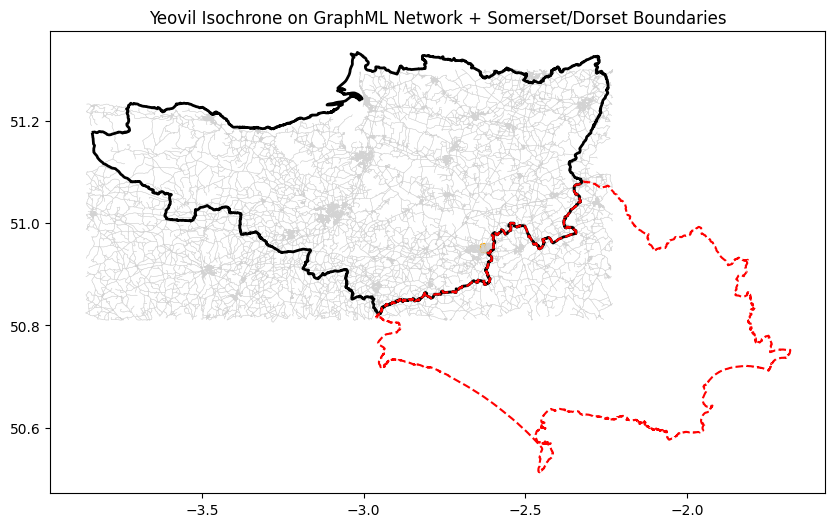

In [19]:
import osmnx as ox
import networkx as nx
import geopandas as gpd
from alphashape import alphashape
import matplotlib.pyplot as plt

# Load GraphML
G = ox.load_graphml("somerset_geojson_files/somerset_road_network_bb.graphml")
nodes, edges = ox.graph_to_gdfs(G)

# Yeovil coordinates
lat, lon = 50.9448, -2.6343

# Compute isochrone
center_node = ox.distance.nearest_nodes(G, lon, lat)
subG = nx.ego_graph(G, center_node, radius=10, distance="time")
pts = [(d["x"], d["y"]) for _, d in subG.nodes(data=True)]
poly = alphashape(pts, alpha=30)

# Load boundaries
somerset = ox.geocode_to_gdf("Somersetshire, United Kingdom").to_crs(edges.crs)
dorset   = ox.geocode_to_gdf("Dorset, England, United Kingdom").to_crs(edges.crs)

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
edges.plot(ax=ax, color="lightgrey", linewidth=0.3)
gpd.GeoSeries([poly], crs=edges.crs).plot(ax=ax, facecolor="none", edgecolor="orange", linewidth=2)
somerset.boundary.plot(ax=ax, color="black", linewidth=2)
dorset.boundary.plot(ax=ax, color="red", linewidth=1.5, linestyle="--")

plt.title("Yeovil Isochrone on GraphML Network + Somerset/Dorset Boundaries")
plt.show()